In [ ]:
import gmsh
import os
import time
import numpy as np
from dolfinx.io import gmshio
from mpi4py import MPI
import pyvista as pv
from dolfinx.plot import vtk_mesh
import cv2
import matplotlib.pyplot as plt
import sys
from pathlib import Path

gmsh.initialize(sys.argv)


In [5]:
def remove_duplicate_params(parametricCoords, coords):
    parametricCoords = np.array(parametricCoords)
    coords = np.array(coords)
    
    _, unique_indices = np.unique(parametricCoords, return_index=True)
    
    return parametricCoords[unique_indices], coords[unique_indices]

In [6]:
def stitch_curves(curves, tol=1e-10):
    """
    Stitch curves given as lists of coordinate lists, based on shared endpoints.

    Parameters:
    - curves: List of curves, each a list of [x, y] or [x, y, z] coordinates
    - tol: Tolerance for matching points

    Returns:
    - List of ordered coordinates forming one stitched boundary path
    """
    def points_equal(p1, p2):
        return np.allclose(p1, p2, atol=tol)

    curves = curves.copy()
    stitched = curves.pop(0)

    while curves:
        stitched_one = False  # Flag to check if we stitched a curve in this pass

        for i in range(len(curves)):
            curve = curves[i]
            if points_equal(curve[0], stitched[-1]):
                stitched += curve[1:]
            elif points_equal(curve[-1], stitched[-1]):
                stitched += curve[-2::-1]
            elif points_equal(curve[0], stitched[0]):
                stitched = curve[-1:0:-1] + stitched
            elif points_equal(curve[-1], stitched[0]):
                stitched = curve[:-1] + stitched
            else:
                continue  # Curve didn't match, try next one
            curves.pop(i)
            stitched_one = True
            break  # Start over since curves list has changed

        if not stitched_one:
            print("Could not stitch any curve in this pass — possibly disconnected.")
            break

    return stitched

In [7]:
def get_surface_contour(boundary_surfaces):
    list_all_contours = []
    #print("boundary_surfaces: ", boundary_surfaces)
    for boundary_surface in boundary_surfaces:
        #print("boundary_surface: ", boundary_surface)
        list_contours = []
        _, array_curve_tags = gmsh.model.occ.getCurveLoops(boundary_surface)
        #print("array_curve_tags: ", array_curve_tags)
        for array_curve_tag in array_curve_tags:
            list_coords = []
            for curve_tag in array_curve_tag:
                #print("curve tag: ", curve_tag)
                _, coords, parametricCoords = gmsh.model.mesh.getNodes(dim = 1, tag = curve_tag, includeBoundary=True)
                coords = np.reshape(coords, (-1, 3))[:, 0:2] # reshape to (n_points, 3) and  omit z-coordinates
                parametricCoords, coords = remove_duplicate_params(parametricCoords, coords)
                sorted_coords = [x for _, x in sorted(zip(parametricCoords, coords))] # abs(parametricCoords) does weird things... 
                list_coords.append(sorted_coords)
            list_contours.append(list_coords)
        
        #print("total number of contours: ", len(list_contours))

        conc_list_contours = []
        for contour in list_contours:
            #print("nr of segments in contour: ", len(contour))
            #print("contour: ", contour)
            stitched = stitch_curves(contour)
            #print("stitched: ", len(stitched))
            # Flatten all curves into a single list of coordinate arrays
            conc_list_contours.append(stitched)
        list_all_contours.append(conc_list_contours)

    return list_all_contours

In [ ]:
def map_to_grid(coords, printing_dimensions, image_size):
    """
    Maps real-world (x, y) coordinates (floats) to discrete image grid indices.

    Parameters:
    - coords: tuple or list of (x, y)
    - printing_dimensions: physical dimensions [width, height]
    - image_size: image dimensions [width_px, height_px]

    Returns:
    - (i, j): mapped pixel coordinates (integer indices)
    """
    x, y = coords
    pw, ph = printing_dimensions
    iw, ih = image_size

    # Normalize to range [0, 1]
    u = (x + pw / 2) / pw
    v = (ph / 2 - y) / ph

    # Map to pixel coordinates
    i = int(np.rint(u * iw))
    j = int(np.rint(v * ih))

    return i, j

In [9]:
def polygons_to_mask(list_all_contours, image_size, printing_dimensions):
    """
    Converts a list of 2D polygons into a single 2D binary mask.

    Parameters:
    - polygons: list of polygons, where each polygon is a list of (x, y) tuples.
    - image_size: (height, width) of the output mask.

    Returns:
    - A 2D numpy array of shape (height, width) with 1s inside the polygons and 0s elsewhere.
    """
    mask = np.zeros(image_size, dtype=np.uint8)

    for list_polygons_points in list_all_contours:
        for polygon in list_polygons_points:
            #print("nr of points in connected curve (aka polygon): ", len(polygon))
            mask_ = np.zeros(image_size, dtype=np.uint8)
            pts = []
            for point in polygon:
                x, y = map_to_grid(point, printing_dimensions, image_size)
                pts.append([x, y])
            pts = np.array([pts], dtype=np.int32)
            cv2.fillPoly(mask_, pts, color=True)
            mask = np.logical_xor(mask, mask_)

    return mask

In [16]:
def plot_mask(mask, output_folder, title="Binary Mask", file_name="default_maskname.png", save: bool = False):
    """
    Plots a 2D binary mask using matplotlib.

    Parameters:
    - mask: 2D numpy array of 0s and 1s.
    - title: Optional title for the plot.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(mask, cmap='gray', interpolation='nearest')
    plt.title(title)
    plt.axis('off')  # Hide axis ticks/labels
    if save:
        plt.savefig(os.path.join(output_folder, file_name), bbox_inches='tight', pad_inches=0.1)
    plt.show()

Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Old bounding box of model: (xmin, ymin, zmin, xmax, ymax, part_height):  (-124.6068404967904, -18.105426778958492, -20.000192957174292, 48.1050402289248, 115.38772611977639, 166.1317194486864) [mm]
Old Midpoint of the model:  [-0.0382509   0.04864115 -0.02000019]
New Midpoint of the model:  [ 0.00000000e+00 -1.38777878e-17  0.00000000e+00]
New bounding box of model: (xmin, ymin, zmin, xmax, ymax, part_height):  (-86.3559403628576, -66.74657644936747, -20.000192957174292, 86.3559403628576, 66.74657644936744, 166.1317194486864) [mm]
This many files will be generated:  332
Continuing...
Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Info    : Snapping geometry point 63 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 66 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 69 to curve (dista

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (BSpline)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (BSpline)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)
Info    : [ 10%] Meshing c

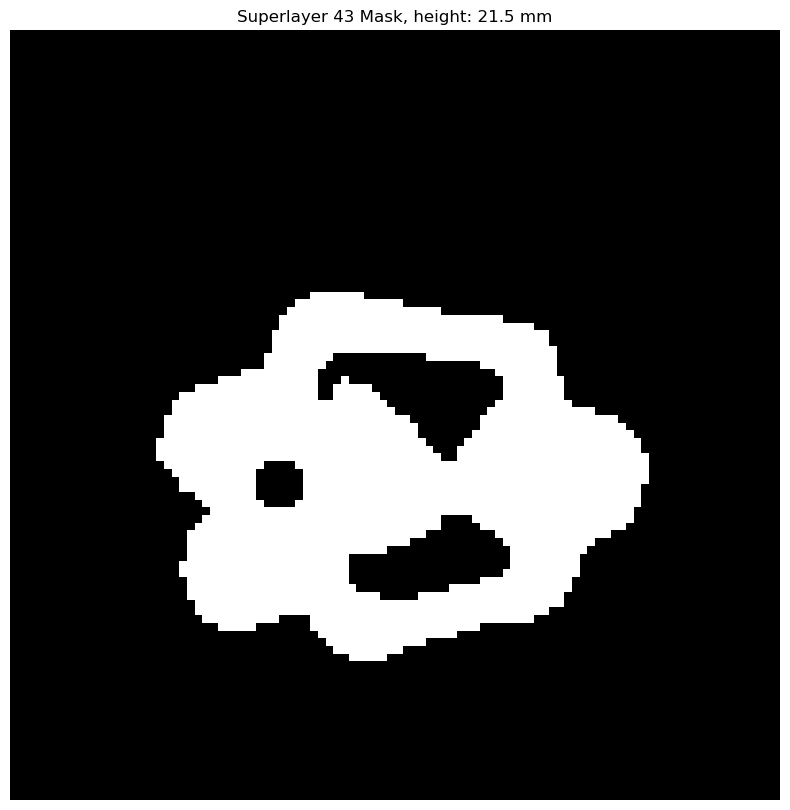

Info    : Snapping geometry point 108 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 108 to curve (distance = 1.5125e-08)
Info    : Removing duplicate mesh nodes...
Info    : Found 0 duplicate nodes 
Info    : No duplicate nodes found
Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Info    : Snapping geometry point 63 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 66 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 69 to curve (distance = 1.6589e-06)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 84 to curve (distance = 2.20385e-07)
Info    : Snapping geometry point 87 to curve (distance = 1.3684e-06)
Info    : Snapping geometry point 128 to curve (distance = 4.855e-06)
Info    : Cannot bind existing OpenCASCADE volume 2 to second tag 1        

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (BSpline)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (BSpline)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)
Info    : [ 10%] Meshing c

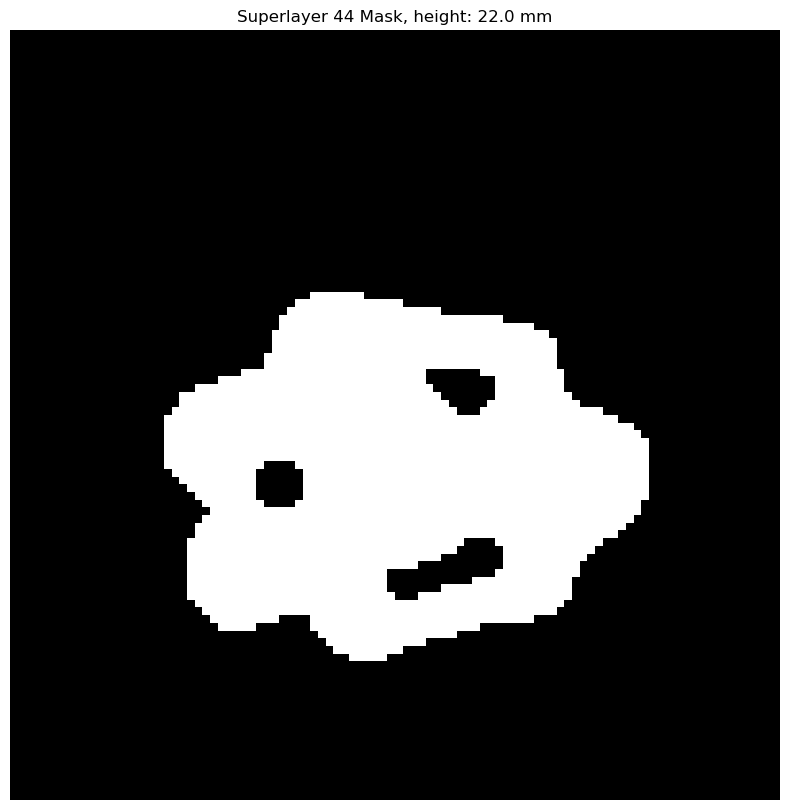

Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Removing duplicate mesh nodes...
Info    : Found 0 duplicate nodes 
Info    : No duplicate nodes found
Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Info    : Snapping geometry point 63 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 66 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 69 to curve (distance = 1.6589e-06)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 84 to curve (distance = 2.20385e-07)
Info    : Snapping geometry point 87 to curve (distance = 1.3684e-06)
Info    : Snapping geometry point 128 to curve (distance = 4.855e-06)
Info    : Cannot bind existing OpenCASCADE volume 2 to second tag 1        

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (BSpline)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (BSpline)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)
Info    : [ 10%] Meshing c

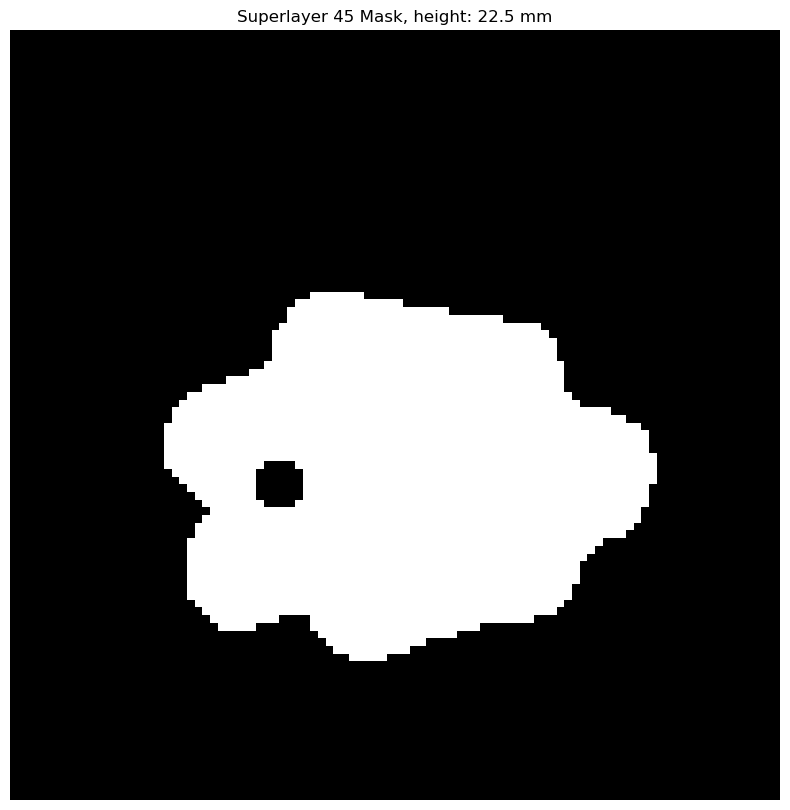

Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 173 to curve (distance = 3.17872e-08)
Info    : Snapping geometry point 173 to curve (distance = 3.17872e-08)
Info    : Removing duplicate mesh nodes...
Info    : Found 0 duplicate nodes 
Info    : No duplicate nodes found
Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Info    : Snapping geometry point 63 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 66 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 69 to curve (distance = 1.6589e-06)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 84 to curve (distance = 2.20385e-07)
Info    : Snapping geometry point 87 to curve (distance = 1.3684e-06)
I

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (BSpline)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (BSpline)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)
Info    : [ 10%] Meshing c

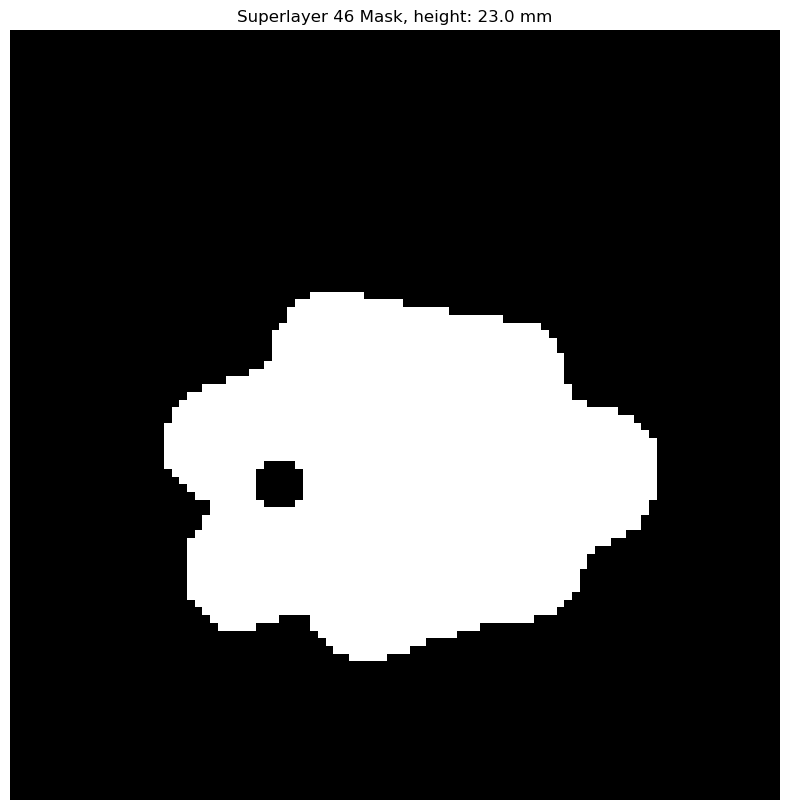

Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Removing duplicate mesh nodes...
Info    : Found 0 duplicate nodes 
Info    : No duplicate nodes found
Info    :  - Label 'Shapes/bunny v2' (3D)
Info    :  - Color (0.627451, 0.627451, 0.627451) (3D & Surfaces)
Info    : Snapping geometry point 63 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 66 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 69 to curve (distance = 1.6589e-06)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 72 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 84 to curve (distance = 2.20385e-07)
Info    : Snapping geometry point 87 to curve (distance = 1.3684e-06)
Info    : Snapping geometry point 128 to curve (distance = 4.855e-06)


Info    : Cannot bind existing OpenCASCADE volume 2 to second tag 1
Info    : Could not preserve tag of 3D object 1 (->2)
intersected:  [(3, 2)]
Info    : Snapping geometry point 78 to curve (distance = 4.855e-06)                                                                          
Info    : Snapping geometry point 100 to curve (distance = 2.20385e-07)
Info    : Snapping geometry point 101 to curve (distance = 1.3684e-06)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 111 to curve (distance = 4.11941e-06)
Info    : Snapping geometry point 112 to curve (distance = 1.6589e-06)
Info    : Snapping geometry point 114 to curve (distance = 2.0908e-08)
Info    : Snapping geometry point 170 to curve (distance = 5.79701e-08)
Info    : Snapping geometry point 170 to curve (distance = 5.79701e-08)
Info    : Snapping geometry point 174 to curve (distance = 2.16304e-0

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (BSpline)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (BSpline)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)
Info    : [ 10%] Meshing c

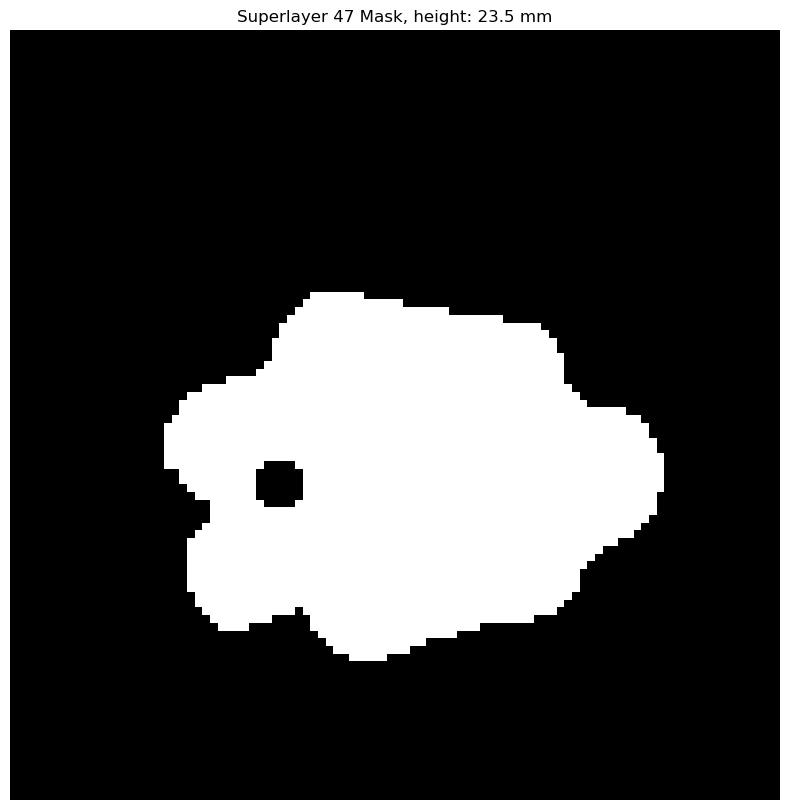

Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 107 to curve (distance = 1.5125e-08)
Info    : Snapping geometry point 170 to curve (distance = 5.79701e-08)
Info    : Snapping geometry point 170 to curve (distance = 5.79701e-08)
Info    : Snapping geometry point 174 to curve (distance = 4.32608e-06)
Info    : Snapping geometry point 174 to curve (distance = 4.32608e-06)
Info    : Removing duplicate mesh nodes...
Info    : Found 0 duplicate nodes 
Info    : No duplicate nodes found
Mesh generation completed.


In [ ]:
def generate_layered_meshes(layer_height, layers_lumping, max_element_size, mask_size, buildplate_dimensions, input_file, output_folder):
    if not gmsh.isInitialized():
        gmsh.initialize()
    else: 
        gmsh.clear()
    gmsh.option.setNumber("General.Terminal", 1)

    gmsh.option.setString('Geometry.OCCTargetUnit', 'M')
    initializer = gmsh.model.occ.importShapes(input_file)[0][1] # returns [(dim, tag)] resp only "tag" with [0][1]
    gmsh.model.occ.synchronize()

    xmin, ymin, zmin, xmax, ymax, part_height = gmsh.model.getBoundingBox(3, initializer)
    print("Old bounding box of model: (xmin, ymin, zmin, xmax, ymax, part_height): ", (xmin*1000, ymin*1000, zmin*1000, xmax*1000, ymax*1000, part_height*1000), "[mm]")
    midpoint = np.array([xmin + (xmax - xmin) / 2, ymin + (ymax - ymin) / 2, zmin])
    print("Old Midpoint of the model: ", midpoint)
    gmsh.model.occ.translate([(3, initializer)], - midpoint[0], - midpoint[1], 0) # translate the model to the origin
    gmsh.model.occ.synchronize()
    xmin, ymin, zmin, xmax, ymax, part_height = gmsh.model.getBoundingBox(3, initializer)
    midpoint_new = np.array([xmin + (xmax - xmin) / 2, ymin + (ymax - ymin) / 2, 0])
    print("New Midpoint of the model: ", midpoint_new)

    n_superlayers = int(part_height / layer_height / layers_lumping)
    superlayer_height = layer_height * layers_lumping
    min_size = superlayer_height / 2

    print("New bounding box of model: (xmin, ymin, zmin, xmax, ymax, part_height): ", (xmin*1000, ymin*1000, zmin*1000, xmax*1000, ymax*1000, part_height*1000), "[mm]")
    print("This many files will be generated: ", n_superlayers)
    
    while True:
        user_input = input("Continue? (yes/no): ").strip().lower()
        #user_input = "yes" # for testing purposes
        if user_input == "yes":
            print("Continuing...")
            break
        elif user_input == "no":
            print("Aborting...")
            return
        else:
            print("Invalid input. Please enter 'yes' or 'no'.")

    gmsh.model.remove()
    gmsh.option.setNumber("Geometry.ToleranceBoolean", value = 1e-6)
    gmsh.option.setNumber("Mesh.AngleToleranceFacetOverlap", 0.1)
    

    os.makedirs(output_folder, exist_ok = True)

    for i in range(43, 48): # range(start, stop [excluding])
    #for i in range(1, n_superlayers + 1): # range(start, stop [excluding])
        gmsh.model.add(f"layer_{i}")
        lz = min(i * superlayer_height, part_height) # current height of the superlayer; min makes sure that last superlayer ends at part height 
        fine_thickness = 3 * superlayer_height # top 3 layers are finer
        fine_start_z = max(0, lz - fine_thickness)
        transition_thickness = 10 * superlayer_height # transition thickness

        dx = xmax - xmin # side length of box in x-direction
        dy = ymax - ymin # side length of box in y-direction
        dz = lz  # side length of box in z-direction

        cutter = gmsh.model.occ.addBox(xmin-0.1, ymin-0.1, -0.1, dx+0.2, dy+0.2, dz+0.1) # returns only the tag of the box (integer)
        gmsh.model.occ.synchronize()

        cut_step = gmsh.model.occ.importShapes(input_file)[0][1] # returns [(dim, tag)]
        # !!! careful: we still need to use the old midpoint for the translation !!! 
        gmsh.model.occ.translate([(3, cut_step)], - midpoint[0], - midpoint[1], - midpoint[2]) # translate the model to the origin

        gmsh.model.occ.synchronize()

        intersected, _ = gmsh.model.occ.intersect([(3, cut_step)], [(3, cutter)],
                            removeObject=True, removeTool=True)
        print("intersected: ", intersected)
        gmsh.model.occ.removeAllDuplicates()
        gmsh.model.occ.synchronize()

        box_id = gmsh.model.mesh.field.add("Box")
        gmsh.model.mesh.field.setNumber(box_id, "VIn", min_size)
        gmsh.model.mesh.field.setNumber(box_id, "VOut", max_element_size)
        gmsh.model.mesh.field.setNumber(box_id, "XMin", xmin)
        gmsh.model.mesh.field.setNumber(box_id, "XMax", xmax)
        gmsh.model.mesh.field.setNumber(box_id, "YMin", ymin)
        gmsh.model.mesh.field.setNumber(box_id, "YMax", ymax)
        gmsh.model.mesh.field.setNumber(box_id, "ZMin", fine_start_z)
        gmsh.model.mesh.field.setNumber(box_id, "ZMax", lz)
        gmsh.model.mesh.field.setNumber(box_id, "Thickness", transition_thickness) # transition thickness 
        gmsh.model.mesh.field.setAsBackgroundMesh(box_id)

        gmsh.option.setNumber("Mesh.MeshSizeMax", max_element_size)
        gmsh.model.occ.synchronize()

        volumes = [] 
        for dim, tag in intersected:
            volumes.append(tag)

        #print("Number of discrete volumes: ", len(volumes))

        gmsh.model.addPhysicalGroup(3, volumes, tag = 1) 
        gmsh.model.setPhysicalName(3, 1, f"volume_of_superlayer_{i}")

        surfaces = gmsh.model.getBoundary(intersected, oriented=False, recursive=False)
        top, bottom, sides = [], [], []
        for dim, tag in surfaces:
            _, _, com_z = gmsh.model.occ.getCenterOfMass(dim, tag) # returns the center of mass of each surface: (x, y, z) where we only care about z
            #print("com_z: ", com_z*1000, "[mm]")
            if abs(com_z - lz) < 1e-6:
                top.append(tag)
                gmsh.model.geo.mesh.setTransfiniteSurface(tag)
            elif abs(com_z) < 1e-6:
                bottom.append(tag)
                gmsh.model.geo.mesh.setTransfiniteSurface(tag)
            else:
                sides.append(tag)
        
        gmsh.model.addPhysicalGroup(2, top, tag=13)
        gmsh.model.setPhysicalName(2, 13, "top")

        gmsh.model.addPhysicalGroup(2, bottom, tag=14)
        gmsh.model.setPhysicalName(2, 14, "bottom")

        gmsh.model.addPhysicalGroup(2, sides, tag=15)
        gmsh.model.setPhysicalName(2, 15, "sides")

        gmsh.model.mesh.generate(2)
        gmsh.model.occ.synchronize()

        boundary_surfaces = gmsh.model.getEntitiesForPhysicalGroup(dim = 2, tag = 13) # [2 9]
        #print("boundary_surfaces: ", boundary_surfaces)

        # "list_contours" has shape "nr of surfaces" x "nr of curves of surface" x "nr of points on curve" x "dimension (x, y)"
        list_all_contours = get_surface_contour(boundary_surfaces) 
        #print("list_all_contours: ", list_all_contours)

        # Now generate a mask
        mask = polygons_to_mask(list_all_contours, mask_size, buildplate_dimensions)
        mask_path = os.path.join(output_folder, f"mask_{i:05d}")
        np.save(mask_path, mask)
        plot_mask(mask, output_folder, title=f"Superlayer {i} Mask, height: {lz*1000} mm", file_name=f"mask_{i:05d}.png", save=True)

        gmsh.model.geo.removeAllDuplicates()
        gmsh.model.occ.synchronize()

        #gmsh.model.mesh.generate(3)
        gmsh.model.mesh.removeDuplicateNodes()

        #gmsh.model.mesh.optimize("Netgen")

        mesh_path = os.path.join(output_folder, f"superlayer_{i:05d}.msh")
        #gmsh.write(mesh_path)
        gmsh.model.remove()

    gmsh.finalize()


# ---- Run it ----
if __name__ == "__main__":
    layer_height = 50 * 1e-6 # converts um to m 
    layers_lumping = 10
    max_element_size = 1 * 1e-3 # converts mm to m

    mask_size = (100, 100) # in ([px], [px])
    buildplate_dimensions = (0.2, 0.2) # in ([m], [m]) 

    input_file="bunny2.step"
    output_folder="bunny_superlayers_10_lumped"

    generate_layered_meshes(
        layer_height, 
        layers_lumping = layers_lumping, 
        max_element_size = max_element_size, 
        mask_size = mask_size,
        buildplate_dimensions = buildplate_dimensions,
        input_file=input_file, 
        output_folder=output_folder)
    
    print("Mesh generation completed.")

In [ ]:
def load_first_layer(msh_file):
    # Convert mesh if needed and import
    print(type(msh_file))
    mesh_, cell_tags, facet_tags = gmshio.read_from_msh(msh_file, comm = MPI.COMM_WORLD, rank=0, gdim=3)
    return mesh_, cell_tags, facet_tags


def plot_dolfinx_mesh(mesh_, cell_type=3):
    """
    Plot a dolfinx mesh using PyVista.
    
    Parameters:
    - mesh: dolfinx.cpp.mesh.Mesh
    - cell_type: 2 for triangle (2D), 3 for tetrahedron (3D)
    """
    grid = pv.UnstructuredGrid(*vtk_mesh(mesh_, mesh_.topology.dim))

    plotter = pv.Plotter()
    plotter.add_mesh(grid, show_edges=True, color="lightblue", opacity=0.7)
    plotter.show()

In [ ]:
def write_partitioned_mesh(filename: Path):
    import subprocess
    from mpi4py import MPI
    import dolfinx
    import adios4dolfinx

    mesh, cell_tags, facet_tags = load_first_layer(os.path.join("layers", "layer_42.msh"))
    
    # Write mesh checkpoint
    adios4dolfinx.write_mesh(filename, mesh, engine="BP4", store_partition_info=True)
    adios4dolfinx.write_meshtags(filename, mesh, cell_tags, engine="BP4", meshtag_name = "cells")
    adios4dolfinx.write_meshtags(filename, mesh, facet_tags, engine="BP4", meshtag_name = "facets")
    # Inspect checkpoint on rank 0 with `bpls`
    if mesh.comm.rank == 0:
        output = subprocess.run(["bpls", "-a", "-l", filename], capture_output=True)
        print(output.stdout.decode("utf-8"))


def read_partitioned_mesh(filename: Path, read_from_partition: bool = True):
    from mpi4py import MPI

    import adios4dolfinx

    prefix = f"{MPI.COMM_WORLD.rank + 1}/{MPI.COMM_WORLD.size}: "
    try:
        mesh = adios4dolfinx.read_mesh(
            filename, comm=MPI.COMM_WORLD, engine="BP4", read_from_partition=read_from_partition
        )
        cell_tags = adios4dolfinx.read_meshtags(filename, mesh, meshtag_name = "cells", engine="BP4")
        facet_tags = adios4dolfinx.read_meshtags(filename, mesh, meshtag_name = "facets", engine="BP4")

        tdim = mesh.topology.dim
        mesh.topology.create_connectivity(tdim - 1, tdim)

        print(f"{prefix} Mesh: {mesh.name} read successfully with {read_from_partition=}")
    except ValueError as e:
        print(f"{prefix} Caught exception: ", e)

    return mesh, cell_tags, facet_tags

In [6]:
%%px 

import time 

mesh_file = Path("./partitioned_meshes/00005.bp")
#write_partitioned_mesh(mesh_file)

start_time = time.time()
mesh2, cell_tags2, facet_tags2 = read_partitioned_mesh(mesh_file, True)
end_time = time.time()
print(f"Time taken to read mesh: {(end_time - start_time)*1000} ms")
print(f"Loaded mesh with {mesh1.topology.index_map(3).size_local} cells.")
#print(len(mesh.cell_tags.values), "DOFs for this process")

[5:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[5], line 7
      4 #write_partitioned_mesh(mesh_file)
      6 start_time = time.time()
----> 7 mesh2, cell_tags2, facet_tags2 = read_partitioned_mesh(mesh_file, True)
      8 end_time = time.time()
      9 print(f"Time taken to read mesh: {(end_time - start_time)*1000} ms")

NameError: name 'read_partitioned_mesh' is not defined
[0:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[5], line 7
      4 #write_partitioned_mesh(mesh_file)
      6 start_time = time.time()
----> 7 mesh2, cell_tags2, facet_tags2 = read_partitioned_mesh(mesh_file, True)
      8 end_time = time.time()
      9 print(f"Time taken to read mesh: {(end_time - start_time)*1000} ms")

NameError: name 'read_partitioned_mesh' is not de

AlreadyDisplayedError: 10 errors

In [ ]:
%%px 

import cProfile, pstats
profiler = cProfile.Profile()
profiler.enable()
_, _, _ = _(os.path.join("layers", "layer_42.msh")) # /mnt/ramdisk/ slower than layers
profiler.disable()
stats = pstats.Stats(profiler).sort_stats('ncalls')
stats.print_stats()

In [69]:
%%px 

mesh1, cell_tags1, facet_tags1 = load_first_layer(os.path.join("layers", "layer_66.msh"))

print(f"Loaded mesh with {mesh1.topology.index_map(3).size_local} cells.")

#plot_dolfinx_mesh(mesh1)


[stdout:0] <class 'str'>
Info    : Reading 'layers/layer_66.msh'...
Info    : 27 entities
Info    : 183760 nodes
Info    : 1122936 elements
Info    : Done reading 'layers/layer_66.msh'
Loaded mesh with 373908 cells.


[stdout:1] <class 'str'>
Loaded mesh with 373778 cells.


[stdout:2] <class 'str'>
Loaded mesh with 373784 cells.


%px:   0%|          | 0/3 [00:00<?, ?tasks/s]